# Data Visualization

## Data Visualization

* https://matplotlib.org/stable/gallery/index.html 
* http://seaborn.pydata.org/examples/
* https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html 
* https://towardsdatascience.com/a-complete-guide-to-plotting-categorical-variables-with-seaborn-bfe54db66bec

### Some Types of Plots

https://towardsdatascience.com/intro-to-dynamic-visualization-with-python-animations-and-interactive-plots-f72a7fb69245

* Static
* Dynamic
* Interactive

In [1]:
# get data
import pandas as pd

grades = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/class-grades4.csv', index_col=0)
grades.drop(['index'], axis=1, inplace=True)
print(grades.shape)
print(grades.info())
grades.head()

(103, 17)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 103 entries, 0 to 102
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prefix       103 non-null    float64
 1   Assignment1  99 non-null     float64
 2   Tutorial     92 non-null     float64
 3   Midterm      95 non-null     float64
 4   Quiz         95 non-null     float64
 5   Final        99 non-null     float64
 6   TakeHome     96 non-null     object 
 7   Student      103 non-null    int64  
 8   Misc         2 non-null      float64
 9   Nothing      0 non-null      float64
 10  FinalGrade   99 non-null     float64
 11  work_status  96 non-null     object 
 12  scholarship  103 non-null    object 
 13  name         103 non-null    object 
 14  age          103 non-null    float64
 15  sex          103 non-null    object 
 16  home.dest    71 non-null     object 
dtypes: float64(10), int64(1), object(6)
memory usage: 14.5+ KB
None


,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,TakeHome,Student,Misc,Nothing,FinalGrade,work_status,scholarship,name,age,sex,home.dest
0,4.0,86.86,62.64,61.0,61.0,62.78,B,1,NaN,NaN,71.0,not_employed,no,"Rice, Master. Albert",10.0,male,NaN
1,4.0,87.93,99.47,72.0,72.0,61.11,B,1,NaN,NaN,71.0,not_employed,no,"Goodwin, Miss. Jessie Allis",10.0,female,"Wiltshire, England Niagara Falls, NY"
2,5.0,57.14,34.09,72.0,72.0,52.50,F,1,0.0,NaN,54.0,half_time,no,"Goodwin, Master. William Frederick",11.0,male,"Wiltshire, England Niagara Falls, NY"
3,6.0,90.74,89.64,NaN,NaN,NaN,A,1,NaN,NaN,NaN,not_employed,no,"Carter, Master. William Thornton II",11.0,male,"Bryn Mawr, PA"
4,6.0,28.14,58.51,71.0,71.0,68.33,D,1,NaN,NaN,60.0,not_employed,yes,"Andersson, Miss. Sigrid Elisabeth",11.0,female,"Sweden Winnipeg, MN"


In [2]:
grades.describe()

,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,Student,Misc,Nothing,FinalGrade,age
count,103.000000,99.000000,92.000000,95.000000,95.000000,99.000000,103.0,2.0,0.0,99.000000,103.000000
mean,7.339806,84.662626,88.593478,69.936842,69.936842,68.178990,1.0,0.0,NaN,75.020202,16.004854
std,0.934664,14.088103,16.489316,10.137156,10.137156,18.593895,0.0,0.0,NaN,13.555615,2.392282
min,4.000000,28.140000,34.090000,46.000000,46.000000,28.060000,1.0,0.0,NaN,51.000000,10.000000
25%,7.000000,80.440000,83.170000,63.000000,63.000000,52.915000,1.0,0.0,NaN,65.500000,15.000000
50%,8.000000,89.940000,92.690000,70.000000,70.000000,66.110000,1.0,0.0,NaN,73.000000,17.000000
75%,8.000000,95.000000,100.097500,77.000000,77.000000,83.610000,1.0,0.0,NaN,86.000000,18.000000
max,8.000000,100.830000,112.580000,94.000000,94.000000,108.890000,1.0,0.0,NaN,104.000000,18.500000


<AxesSubplot: >

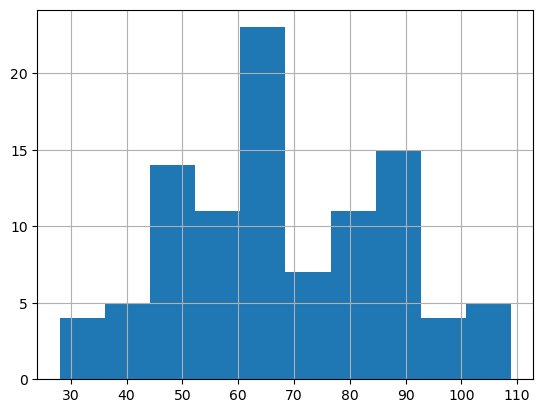

In [3]:
# histogram
grades['Final'].hist()

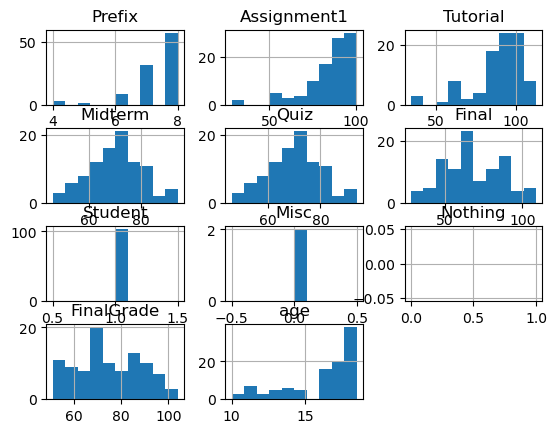

In [4]:
grades.hist();

In [5]:
grades._get_numeric_data().columns

Index(['Prefix', 'Assignment1', 'Tutorial', 'Midterm', 'Quiz', 'Final',
       'Student', 'Misc', 'Nothing', 'FinalGrade', 'age'],
      dtype='object')

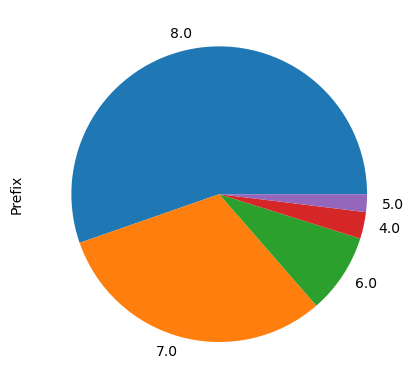

In [6]:
# pie plot
grades['Prefix'].value_counts().plot(kind='pie');

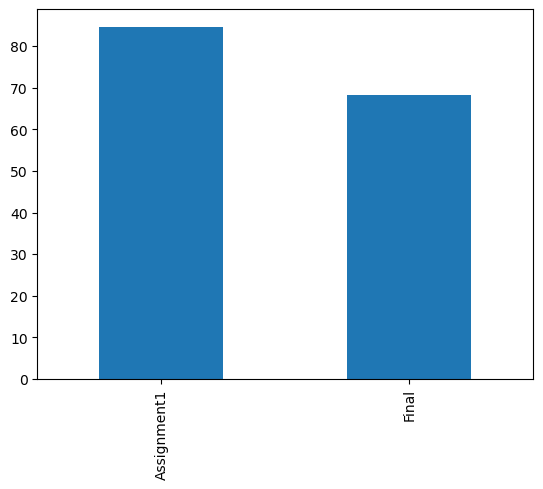

In [7]:
# bar plot
grades[['Assignment1', 'Final']].mean().plot(kind='bar');

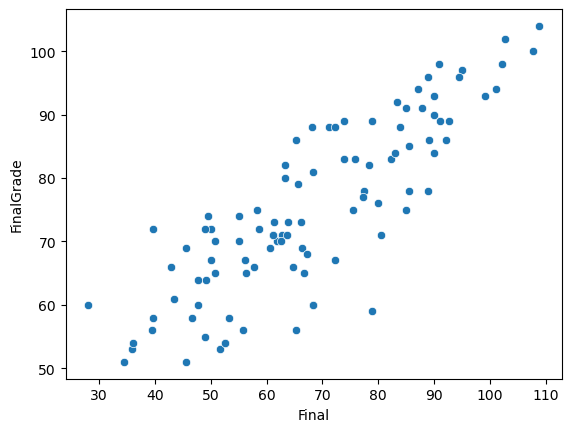

In [8]:
# bivariate
import seaborn as sns

sns.scatterplot(data=grades, x='Final', y='FinalGrade');

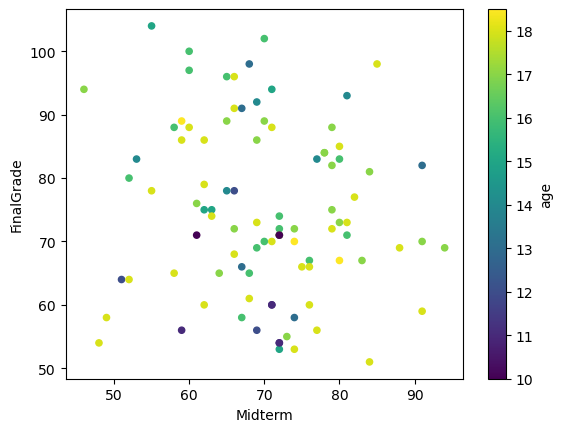

In [9]:
# multivariate
grades.plot.scatter(x='Midterm', y='FinalGrade', c='age', colormap='viridis');

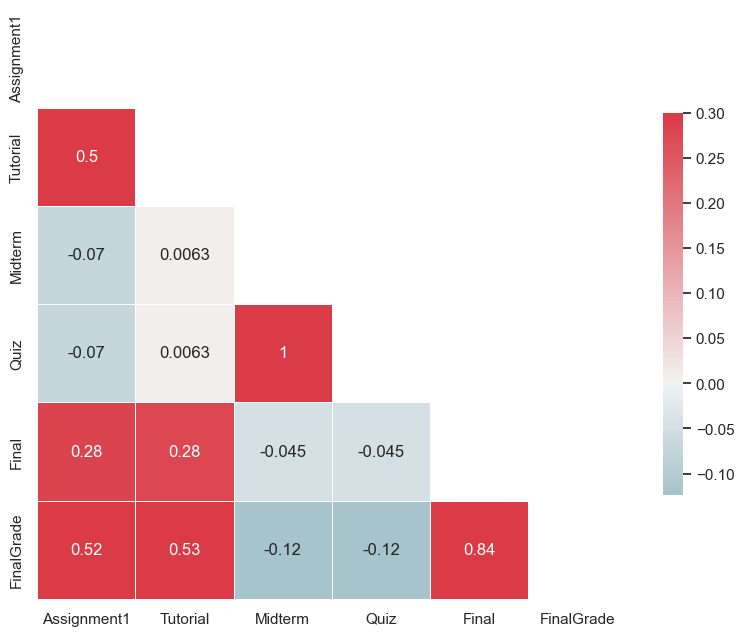

In [10]:
# correlation heat map
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# correlation matrix
sns.set(style="white")

# compute the correlation matrix
corr = grades[['Assignment1', 'Tutorial', 'Midterm', 'Quiz', 'Final', 'FinalGrade']].corr()

# generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# set up the matplotlib figure
# f, ax = plt.subplots()
f = plt.figure(figsize=(8, 8))

# generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True);

plt.tight_layout()

## Groupby 

https://towardsdatascience.com/meet-the-hardest-functions-of-pandas-part-ii-f8029a2b0c9b

In [11]:
# groupby
grades.groupby('sex')['Final'].agg(['min', 'max', 'mean'])

,min,max,mean
sex,,,
female,34.44,108.89,69.255532
male,28.06,107.78,67.205962


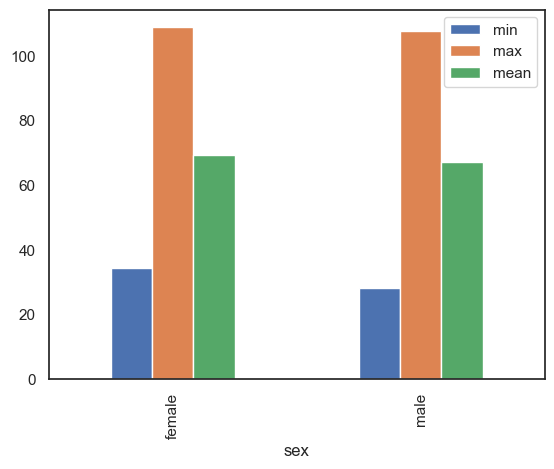

In [12]:
# bar chart; https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
grades.groupby('sex')['Final'].agg(['min', 'max', 'mean']).plot(kind='bar');

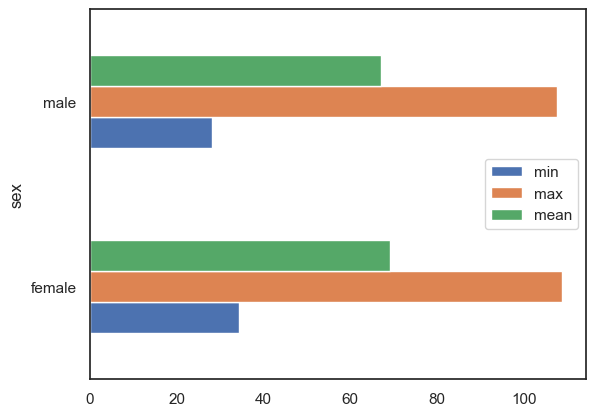

In [13]:
# horizontal bar chart
grades.groupby('sex')['Final'].agg(['min', 'max', 'mean']).plot(kind='barh');

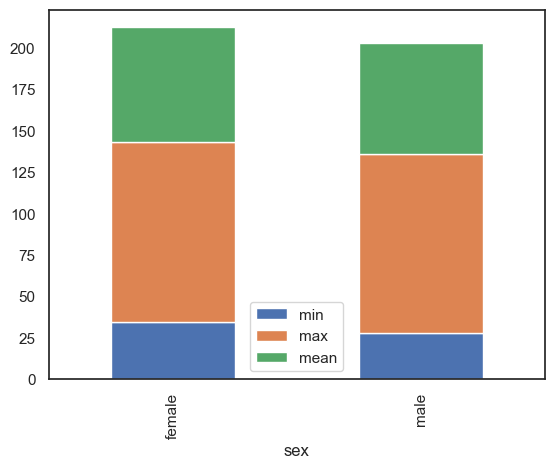

In [14]:
# stacked bar
grades.groupby('sex')['Final'].agg(['min', 'max', 'mean']).plot.bar(stacked=True);

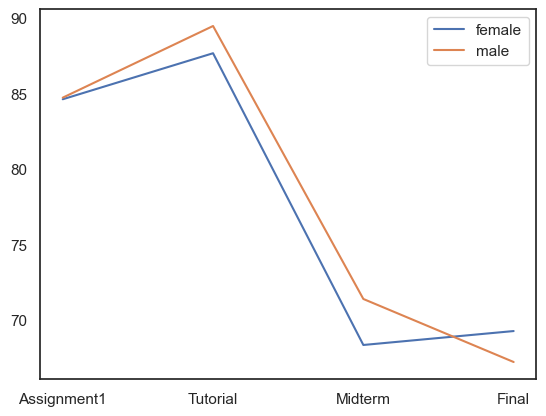

In [15]:
# plot 4 grades grouped by sex
import matplotlib.pyplot as plt

female_scores = grades.query('`sex` == "female"')
male_scores = grades.query('`sex` == "male"')
ax = female_scores[['Assignment1', 'Tutorial', 'Midterm', 'Final']].mean().plot(kind='line', label='female')
male_scores[['Assignment1', 'Tutorial', 'Midterm', 'Final']].mean().plot(ax=ax, label='male')
plt.legend()
plt.show()

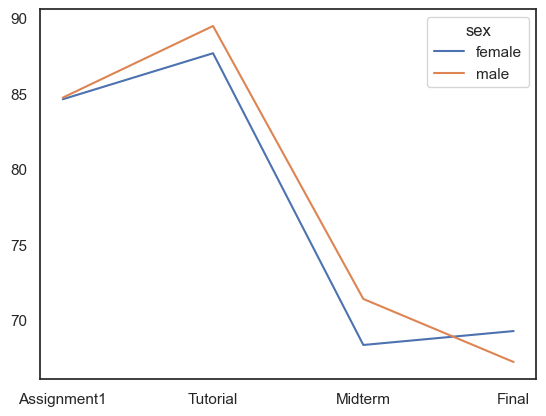

In [16]:
# groupby plot one liner
grades.groupby('sex')[['Assignment1', 'Tutorial', 'Midterm', 'Final']].agg('mean').transpose().plot(kind='line');

        Assignment1   Tutorial    Midterm      Final
sex                                                 
female    84.604889  87.652727  68.333333  69.255532
male      84.710741  89.455833  71.380000  67.205962
------------------------------------------------------------
sex             female       male
Assignment1  84.604889  84.710741
Tutorial     87.652727  89.455833
Midterm      68.333333  71.380000
Final        69.255532  67.205962
------------------------------------------------------------


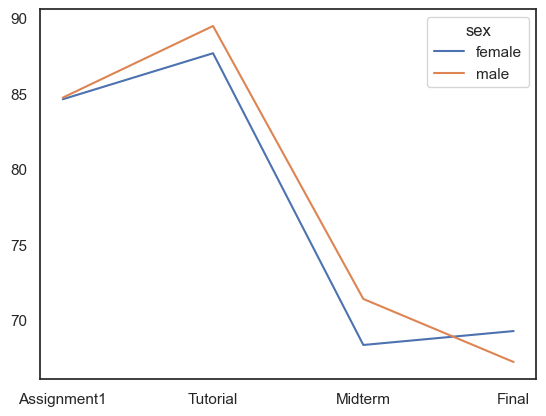

In [17]:
# groupby breakdown
grouped = grades.groupby('sex')[['Assignment1', 'Tutorial', 'Midterm', 'Final']].agg('mean')
print(grouped)
print('---' * 20)
print(grouped.transpose())
print('---' * 20)
grouped.transpose().plot(kind='line');

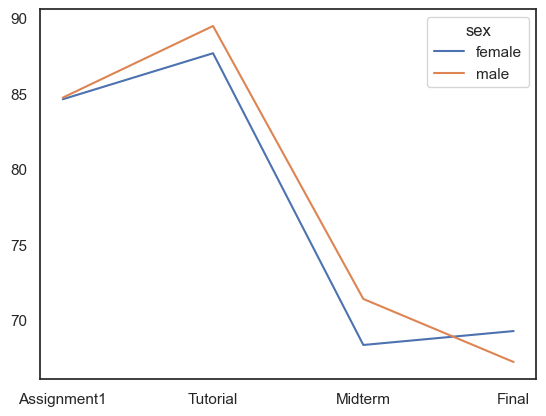

In [18]:
# groupby two liner
grouped = grades.groupby('sex')[['Assignment1', 'Tutorial', 'Midterm', 'Final']].agg('mean')
grouped.transpose().plot(kind='line');